# Justificación Estadística del Problema
## Sistema de Seguridad IoT para Cocinas Industriales

**Universidad Industrial de Santander (UIS)**

**Autores:**
Cesar
Carlos
Ivan

**Proyecto:** Sistema de seguridad en cocinas industriales basado en IoT (ESP32)

**Propósito de este notebook:** construir, con evidencia estadística rigurosa, la justificación
del problema para el trabajo de grado, respondiendo a la pregunta:

> **¿Existe evidencia estadística suficiente para justificar el desarrollo de un sistema
> automatizado de detección y mitigación de riesgos (temperatura, gas, llama) en cocinas
> industriales?**

Se trabaja con **tres fuentes de datos independientes**, de distinto origen, escala y país,
que se analizan por separado y luego se integran en una síntesis final:

| Dataset | Fuente | Alcance | Filas |
|---|---|---|---|
| **A** | Observatorio de Salud (OSB) — accidentalidad laboral por tipo | Colombia, 2015–2025 | 55 |
| **B** | Positiva ARL — Estadísticas de Riesgos Laborales | Colombia, corte junio 2026 (nacional) | 61.816 |
| **C** | U.S. Bureau of Labor Statistics (BLS) — Survey of Occupational Injuries and Illnesses (SOII) | Estados Unidos, 2014–2024 | (decodificado de 241 MB) |

Se aplican herramientas estadísticas: estadística descriptiva, Ley de los Grandes Números, Teorema del Límite Central,
estimación puntual y por intervalos, pruebas de hipótesis, bondad de ajuste, regresión
lineal y no lineal, ANOVA y pronóstico.


## 0. Preparación del entorno

Antes de cargar los datos, se importan las librerías necesarias. Si este notebook se
ejecuta en Google Colab, sube los siguientes 3 archivos a la sesión (ícono de carpeta →
Subir) o móntalos desde Google Drive, y ajusta `DATA_PATH` según corresponda:

- `osb_saludmental-tipodeaccidente.csv`
- `Estadísticas_Riesgos_Laborales_Positiva_2026_20260728.csv`
- `is_data_1.AllData` *(opcional — solo si quieres reproducir la decodificación BLS desde cero;
  el notebook ya incluye la serie decodificada como respaldo, ver sección 4.1)*


In [3]:
# ── LIBRERÍAS ─────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
from tabulate import tabulate

sns.set_style('whitegrid')
plt.rcParams['font.size'] = 11
pd.set_option('display.width', 120)

from google.colab import drive
drive.mount('/content/drive')

# Ruta correcta basada en tu imagen de Google Drive
DATA_PATH = '/content/drive/MyDrive/Proyecto SistemaSeguridadCocinas/datos cocinas/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
# PARTE I — Accidentalidad laboral por tipo (Observatorio de Salud, Colombia 2015–2025)

Este primer dataset registra, año a año entre 2015 y 2025, la frecuencia absoluta y
relativa de 5 tipos de accidente de trabajo: **elemento cortopunzante, elemento
contundente, caída de altura, caída de su propia altura y quemadura**. La categoría
*quemadura* es la de mayor relevancia directa para un sistema de seguridad en cocinas,
por lo que recibe especial atención, sin dejar de lado el panorama general.


## 1.1 Carga y limpieza de datos

El archivo usa `;` como separador, `,` como separador decimal, y el punto como separador
de miles en la columna de frecuencia absoluta (p. ej. `2.237` significa 2237, no dos
enteros con dos decimales). Este último detalle es fácil de pasar por alto — de hecho,
en el notebook exploratorio original esta columna quedó mal interpretada para el año 2024 —
así que aquí se corrige explícitamente leyendo la columna como texto y removiendo los
puntos antes de convertir a entero.


In [4]:
file_salud = DATA_PATH + 'osb_saludmental-tipodeaccidente.csv'
dfA = pd.read_csv(file_salud, sep=';', encoding='utf-8-sig', dtype=str)
dfA = dfA.drop(columns=[c for c in dfA.columns if 'Unnamed' in c])

dfA['Año'] = dfA['Año'].astype(int)
dfA['Frecuencia relativa'] = dfA['Frecuencia relativa'].str.replace(',', '.', regex=False).astype(float)
# La columna de frecuencia absoluta es un conteo entero; el punto es separador de miles, no decimal
dfA['Frecuencia absoluta'] = (dfA['Frecuencia absoluta'].str.strip()
                                                          .str.replace('.', '', regex=False)
                                                          .astype(int))
dfA['Tipo accidente'] = dfA['Tipo accidente'].astype('category')

print(f"Registros: {len(dfA)}   Años: {dfA['Año'].min()}-{dfA['Año'].max()}   Tipos: {dfA['Tipo accidente'].nunique()}")
dfA.head(10)


Registros: 55   Años: 2015-2025   Tipos: 5


,Año,Tipo accidente,Frecuencia absoluta,Frecuencia relativa
0,2015,Elemento Cortopunzante,105,8.7
1,2015,Elemento Contundente,160,13.2
2,2015,Caida de Altura,249,20.6
3,2015,Caida de su Propia Altura,388,32.1
4,2015,Quemadura,127,10.5
5,2016,Elemento Cortopunzante,118,6.7
6,2016,Elemento Contundente,271,15.4
7,2016,Caida de Altura,340,19.3
8,2016,Caida de su Propia Altura,638,36.2
9,2016,Quemadura,199,11.3


## 1.2 Estadística descriptiva por tipo de accidente

Se calculan los estadísticos clásicos (media, mediana, desviación estándar, mínimo,
máximo y coeficiente de variación) de la frecuencia absoluta anual para cada tipo de
accidente, a lo largo de los 11 años disponibles.


In [5]:
desc = dfA.groupby('Tipo accidente', observed=True)['Frecuencia absoluta'].agg(
    ['mean', 'median', 'std', 'min', 'max', 'sum']).round(1)
desc['cv_%'] = (desc['std'] / desc['mean'] * 100).round(1)
desc = desc.sort_values('sum', ascending=False)
desc


,mean,median,std,min,max,sum,cv_%
Tipo accidente,,,,,,,
Caida de su Propia Altura,1243.3,950.0,889.1,388,3029,13676,71.5
Caida de Altura,1020.1,733.0,782.0,249,2458,11221,76.7
Quemadura,614.2,570.0,395.1,127,1229,6756,64.3
Elemento Contundente,453.6,314.0,379.0,128,1310,4990,83.6
Elemento Cortopunzante,154.4,118.0,81.5,90,350,1698,52.8


**Análisis:** en los 11 años registrados, *caída de su propia altura* acumula el mayor
número de casos (13.676), seguida de *caída de altura* (11.221) y *quemadura* (6.756).
Sin embargo, todos los tipos muestran coeficientes de variación superiores al 50%, lo que
indica una dispersión alta año a año — consistente con un fenómeno que ha venido
**creciendo de forma sostenida** en la década, más que fluctuando alrededor de un nivel
estable. Esto se explora con más detalle en la sección 1.6.


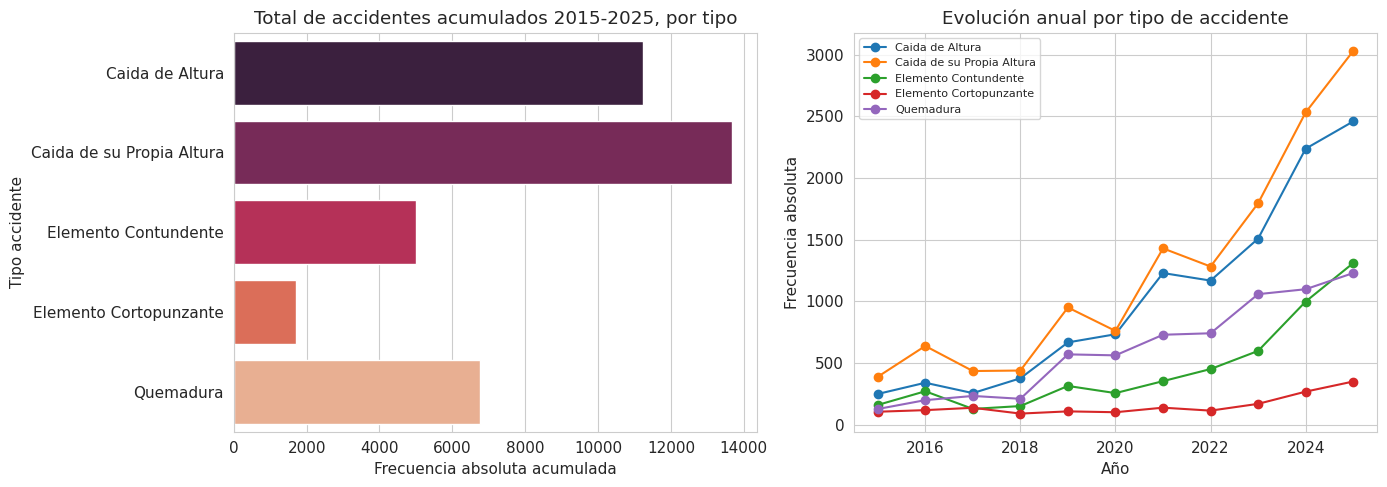

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

orden = desc.index
sns.barplot(x=desc['sum'].values, y=orden, ax=axes[0], palette='rocket', hue=orden, legend=False)
axes[0].set_title('Total de accidentes acumulados 2015-2025, por tipo')
axes[0].set_xlabel('Frecuencia absoluta acumulada')

for tipo in dfA['Tipo accidente'].cat.categories:
    sub = dfA[dfA['Tipo accidente'] == tipo].sort_values('Año')
    axes[1].plot(sub['Año'], sub['Frecuencia absoluta'], marker='o', label=tipo)
axes[1].set_title('Evolución anual por tipo de accidente')
axes[1].set_xlabel('Año'); axes[1].set_ylabel('Frecuencia absoluta')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()


**Análisis:** el gráfico de evolución anual muestra un patrón claro: los cinco tipos de
accidente aumentan de forma casi monótona desde 2015, con una aceleración visible a
partir de 2019. Las quemaduras, en particular, pasan de 127 casos en 2015 a 1.229 en 2025 —
un incremento de casi 10 veces en una década.


## 1.3 Ley de los Grandes Números (LGN) — Serie de quemaduras

La LGN establece que, a medida que aumenta el tamaño de la muestra, la media muestral
converge a la media poblacional. Aquí se ilustra remuestreando (con reemplazo, *bootstrap*)
la serie de 11 observaciones anuales de quemaduras y observando cómo la media de las
remuestras converge rápidamente a la media real de la serie.


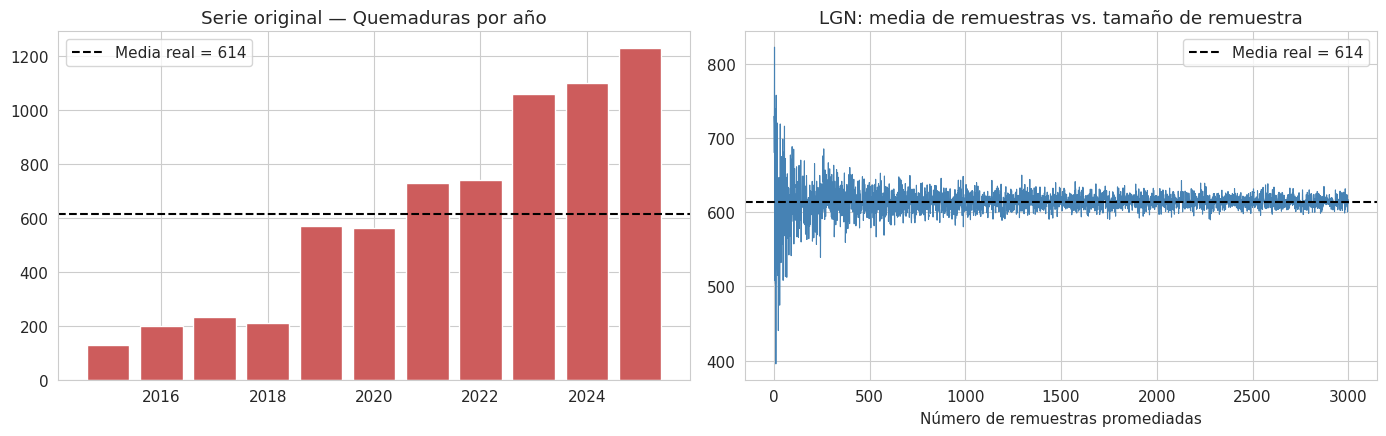

Media real de la serie: 614.2
Media de 3000 remuestras bootstrap: 616.8


In [7]:
quem = dfA[dfA['Tipo accidente'] == 'Quemadura'].sort_values('Año').reset_index(drop=True)
datos_quem = quem['Frecuencia absoluta'].values
media_real = datos_quem.mean()

np.random.seed(42)
tam_muestras = np.arange(1, 3001)
medias_acumuladas = [np.mean(np.random.choice(datos_quem, size=n, replace=True)) for n in tam_muestras]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].bar(quem['Año'], quem['Frecuencia absoluta'], color='indianred')
axes[0].axhline(media_real, color='black', linestyle='--', label=f'Media real = {media_real:.0f}')
axes[0].set_title('Serie original — Quemaduras por año'); axes[0].legend()

axes[1].plot(tam_muestras, medias_acumuladas, color='steelblue', linewidth=0.8)
axes[1].axhline(media_real, color='black', linestyle='--', label=f'Media real = {media_real:.0f}')
axes[1].set_title('LGN: media de remuestras vs. tamaño de remuestra')
axes[1].set_xlabel('Número de remuestras promediadas'); axes[1].legend()
plt.tight_layout()
plt.show()

print(f"Media real de la serie: {media_real:.1f}")
print(f"Media de 3000 remuestras bootstrap: {np.mean(medias_acumuladas[-1]):.1f}")


**Análisis:** como predice la LGN, la media de las remuestras se estabiliza rápidamente
alrededor de la media real de la serie (≈614 quemaduras/año) a medida que crece el número
de remuestras promediadas, confirmando que la media muestral es un estimador consistente
de la media poblacional incluso con una serie corta de 11 observaciones.


## 1.4 Teorema del Límite Central (TCL)

Se toman 3.000 muestras aleatorias de tamaño *n* = 15 (con reemplazo) del conjunto
completo de 55 observaciones (los 5 tipos de accidente combinados) y se grafica la
distribución de sus medias, comparándola con la distribución original.


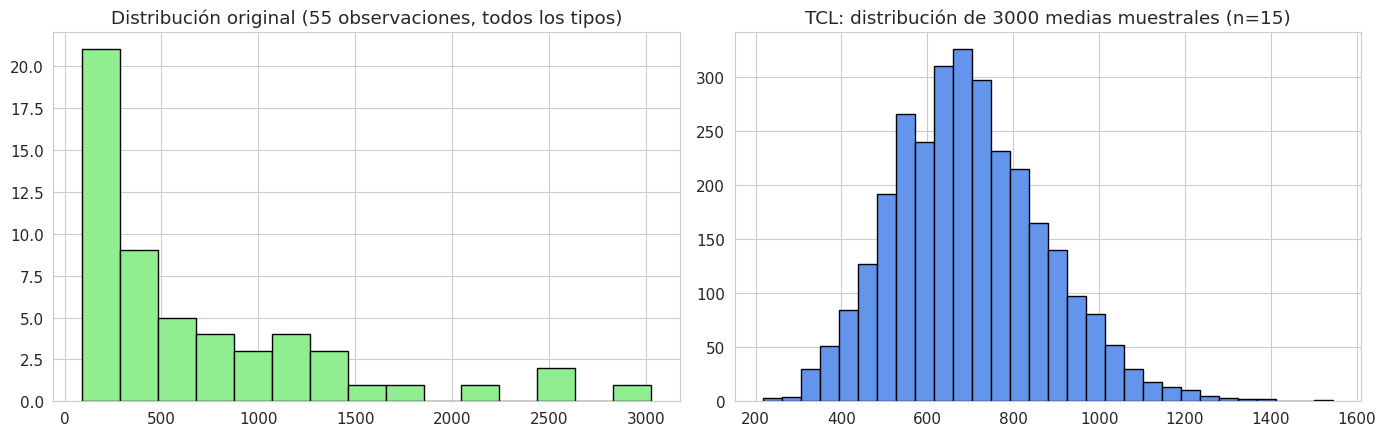

Media poblacional (aprox.): 697.1    Media de las medias muestrales: 697.9
Error estándar teórico: 177.36    Desv. estándar empírica de las medias: 175.90


In [8]:
np.random.seed(7)
todas = dfA['Frecuencia absoluta'].values
n_muestras, tam_muestra = 3000, 15
medias_tcl = [np.mean(np.random.choice(todas, tam_muestra, replace=True)) for _ in range(n_muestras)]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].hist(todas, bins=15, color='lightgreen', edgecolor='black')
axes[0].set_title('Distribución original (55 observaciones, todos los tipos)')

axes[1].hist(medias_tcl, bins=30, color='cornflowerblue', edgecolor='black')
axes[1].set_title(f'TCL: distribución de {n_muestras} medias muestrales (n={tam_muestra})')
plt.tight_layout()
plt.show()

se_teorico = todas.std(ddof=1) / np.sqrt(tam_muestra)
print(f"Media poblacional (aprox.): {todas.mean():.1f}    Media de las medias muestrales: {np.mean(medias_tcl):.1f}")
print(f"Error estándar teórico: {se_teorico:.2f}    Desv. estándar empírica de las medias: {np.std(medias_tcl):.2f}")


**Análisis:** aunque la distribución original (izquierda) es marcadamente asimétrica —
producto de mezclar tipos de accidente con frecuencias muy distintas—, la distribución de
las medias muestrales (derecha) se aproxima a una forma acampanada, tal como predice el
TCL. Además, el error estándar empírico de las medias muestrales coincide de cerca con el
valor teórico ($\sigma/\sqrt{n}$), lo que valida el uso de la distribución normal (o t) para
construir los intervalos de confianza de la siguiente sección.


## 1.5 Estimación puntual y por intervalos — Quemaduras por año

Se calculan los estimadores puntuales clásicos y los intervalos de confianza del 95% para
la media y la varianza poblacional del número anual de quemaduras, usando las
distribuciones *t* de Student y $\chi^2$, respectivamente (apropiadas cuando la varianza
poblacional es desconocida y *n* es pequeño, como es el caso aquí con *n* = 11).


In [9]:
n = len(datos_quem)
media = datos_quem.mean()
mediana = np.median(datos_quem)
var = datos_quem.var(ddof=1)
s = datos_quem.std(ddof=1)
error_est = s / np.sqrt(n)
cv = s / media * 100

print("── Estimación puntual ──")
print(f"n = {n}   media = {media:.1f}   mediana = {mediana:.1f}   varianza = {var:,.0f}   desv.std = {s:.1f}   CV = {cv:.1f}%")

# IC 95% para la media (t de Student, sigma desconocida)
confianza = 0.95
t_crit = stats.t.ppf((1 + confianza) / 2, df=n - 1)
margen = t_crit * error_est
ic_media = (media - margen, media + margen)

# IC 95% para la varianza (Chi-cuadrado)
alpha = 1 - confianza
chi2_l = stats.chi2.ppf(1 - alpha / 2, df=n - 1)
chi2_u = stats.chi2.ppf(alpha / 2, df=n - 1)
ic_var = ((n - 1) * var / chi2_l, (n - 1) * var / chi2_u)

print(f"\n── Intervalos de confianza 95% ──")
print(f"Media poblacional:    {ic_media[0]:.1f}  a  {ic_media[1]:.1f}   (t_crit={t_crit:.3f}, gl={n-1})")
print(f"Varianza poblacional: {ic_var[0]:,.0f}  a  {ic_var[1]:,.0f}   (chi2_L={chi2_l:.2f}, chi2_U={chi2_u:.2f})")


── Estimación puntual ──
n = 11   media = 614.2   mediana = 570.0   varianza = 156,138   desv.std = 395.1   CV = 64.3%

── Intervalos de confianza 95% ──
Media poblacional:    348.7  a  879.6   (t_crit=2.228, gl=10)
Varianza poblacional: 76,228  a  480,873   (chi2_L=20.48, chi2_U=3.25)


**Análisis:** con 95% de confianza, el número medio de quemaduras reportadas por año en
Bogotá se encuentra entre **349 y 880 casos**. El intervalo es amplio — reflejo directo del
alto coeficiente de variación (64.3%) ya identificado — pero incluso en su extremo
inferior representa varios cientos de quemaduras anuales, una cifra que por sí sola
respalda la necesidad de mecanismos de prevención automatizados en los entornos donde
estas lesiones ocurren con mayor frecuencia, como las cocinas.


## 1.6 Prueba de hipótesis — ¿aumentó la participación relativa de las quemaduras?

Los datos muestran un crecimiento evidente en el número **absoluto** de quemaduras, pero
ese crecimiento podría deberse simplemente a que la accidentalidad laboral total también
creció (más trabajadores reportando, más cobertura, etc.). Para aislar si las quemaduras
ganaron **peso relativo** frente a los demás tipos de accidente, se compara la frecuencia
relativa (%) promedio del periodo temprano (2015–2019) contra el periodo tardío
(2021–2025), con 2020 excluido por ser un año atípico (pandemia).

$H_0: \mu_{tardío} = \mu_{temprano}$  vs. $H_1: \mu_{tardío} \neq \mu_{temprano}$


In [10]:
temprano = dfA[(dfA['Tipo accidente'] == 'Quemadura') & (dfA['Año'].between(2015, 2019))]['Frecuencia relativa']
tardio   = dfA[(dfA['Tipo accidente'] == 'Quemadura') & (dfA['Año'].between(2021, 2025))]['Frecuencia relativa']

tstat, pval = stats.ttest_ind(tardio, temprano, equal_var=False)  # Welch, no asume varianzas iguales

print(f"Frecuencia relativa media 2015-2019: {temprano.mean():.2f}%   (valores: {list(temprano.values)})")
print(f"Frecuencia relativa media 2021-2025: {tardio.mean():.2f}%   (valores: {list(tardio.values)})")
print(f"\nPrueba t de Welch: t = {tstat:.3f}   p-valor = {pval:.4f}")
print("Conclusión:", "se rechaza H0 (diferencia significativa)" if pval < 0.05 else "no se rechaza H0 (sin diferencia significativa al 5%)")


Frecuencia relativa media 2015-2019: 14.74%   (valores: [np.float64(10.5), np.float64(11.3), np.float64(17.0), np.float64(14.8), np.float64(20.1)])
Frecuencia relativa media 2021-2025: 16.68%   (valores: [np.float64(16.9), np.float64(18.1), np.float64(19.3), np.float64(14.9), np.float64(14.2)])

Prueba t de Welch: t = 0.959   p-valor = 0.3740
Conclusión: no se rechaza H0 (sin diferencia significativa al 5%)


**Análisis:** con *p* = 0.374, **no hay evidencia suficiente para afirmar que la
participación relativa de las quemaduras haya cambiado significativamente** entre los dos
periodos. Este es un hallazgo importante y matizado: el crecimiento explosivo en el número
absoluto de quemaduras (de 127 a 1.229 casos) **no** se debe a que las quemaduras se hayan
vuelto proporcionalmente más comunes, sino a que **la accidentalidad laboral total ha
crecido**, arrastrando consigo a todos los tipos de accidente por igual — incluidas las
quemaduras, que se han mantenido de forma consistente entre el 10% y el 21% de los
accidentes reportados en esta serie a lo largo de toda la década. Esto refuerza, más que
debilita, la justificación: las quemaduras son y han sido un componente estructural y
significativo de la accidentalidad, no un fenómeno pasajero.


## 1.7 Bondad de ajuste — ¿son los cinco tipos de accidente igualmente frecuentes?

Se aplica una prueba $\chi^2$ de bondad de ajuste para contrastar la hipótesis de que los
5 tipos de accidente ocurren con la misma frecuencia (distribución uniforme), frente a la
alternativa de que existen diferencias reales entre ellos.

$H_0$: los 5 tipos de accidente son igualmente frecuentes
$H_1$: al menos un tipo difiere significativamente de los demás


In [11]:
tot_por_tipo = dfA.groupby('Tipo accidente', observed=True)['Frecuencia absoluta'].sum().sort_values(ascending=False)
obs = tot_por_tipo.values
esperado = np.full(len(obs), obs.sum() / len(obs))

chi2_stat, chi2_p = stats.chisquare(obs, esperado)

tabla = pd.DataFrame({'Observado': obs, 'Esperado (H0)': esperado.round(1)}, index=tot_por_tipo.index)
print(tabla)
print(f"\nChi2 = {chi2_stat:.1f}   gl = {len(obs)-1}   p-valor = {chi2_p:.2e}")


                           Observado  Esperado (H0)
Tipo accidente                                     
Caida de su Propia Altura      13676         7668.2
Caida de Altura                11221         7668.2
Quemadura                       6756         7668.2
Elemento Contundente            4990         7668.2
Elemento Cortopunzante          1698         7668.2

Chi2 = 12045.1   gl = 4   p-valor = 0.00e+00


**Análisis:** el estadístico $\chi^2$ = 12.045,1 con un p-valor prácticamente cero rechaza
contundentemente $H_0$: los tipos de accidente **no** ocurren con la misma frecuencia.
*Caída de su propia altura* y *caída de altura* concentran, juntas, cerca del 65% de los
casos, mientras que las quemaduras representan aproximadamente el 18%. Esto ayuda a
priorizar: un sistema de seguridad para cocinas que atienda además la prevención de
caídas (pisos húmedos, grasa derramada) y no solo el riesgo térmico, atacaría una porción
aún mayor del problema.


## 1.8 Regresión — modelando la tendencia temporal de las quemaduras

Se ajustan dos modelos a la serie temporal de quemaduras (2015–2025): un modelo **lineal**
y un modelo **exponencial** (linealizado con logaritmo natural), y se comparan mediante
$R^2$.


Modelo lineal:      Ŷ = 32.3 + 116.38·(Año-2015)     R² = 0.9542   p(pendiente) = 2.48e-07
Modelo exponencial: Ŷ = 150.4 · e^(0.2317·(Año-2015))   R² = 0.8856   tasa de crecimiento anual ≈ 26.1%


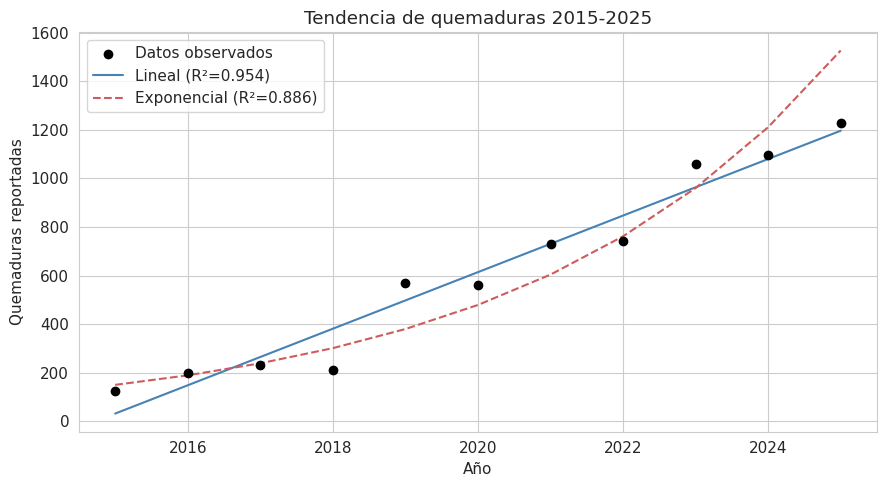

In [12]:
anio = quem['Año'].values
y = quem['Frecuencia absoluta'].values
t = anio - anio.min()   # año centrado en 0 para una intercepción interpretable

# --- Modelo lineal ---
X = sm.add_constant(t)
modelo_lin = sm.OLS(y, X).fit()
b0, b1 = modelo_lin.params
r2_lin = modelo_lin.rsquared
p_pendiente = modelo_lin.pvalues[1]

# --- Modelo exponencial: y = a * e^(b*t) linealizado con ln(y) = ln(a) + b*t ---
b1_exp, b0_exp = np.polyfit(t, np.log(y), 1)
a_exp = np.exp(b0_exp)
y_pred_exp = a_exp * np.exp(b1_exp * t)
r2_exp = 1 - np.sum((y - y_pred_exp)**2) / np.sum((y - y.mean())**2)

print(f"Modelo lineal:      Ŷ = {b0:.1f} + {b1:.2f}·(Año-2015)     R² = {r2_lin:.4f}   p(pendiente) = {p_pendiente:.2e}")
print(f"Modelo exponencial: Ŷ = {a_exp:.1f} · e^({b1_exp:.4f}·(Año-2015))   R² = {r2_exp:.4f}   tasa de crecimiento anual ≈ {(np.exp(b1_exp)-1)*100:.1f}%")

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(anio, y, color='black', zorder=5, label='Datos observados')
ax.plot(anio, modelo_lin.predict(X), color='steelblue', label=f'Lineal (R²={r2_lin:.3f})')
ax.plot(anio, y_pred_exp, color='indianred', linestyle='--', label=f'Exponencial (R²={r2_exp:.3f})')
ax.set_xlabel('Año'); ax.set_ylabel('Quemaduras reportadas'); ax.legend(); ax.set_title('Tendencia de quemaduras 2015-2025')
plt.tight_layout(); plt.show()


**Análisis:** ambos modelos ajustan muy bien la serie ($R^2_{lineal}$ = 0.954,
$R^2_{exp}$ = 0.886), y la pendiente del modelo lineal es significativa a cualquier nivel
usual ($p < 0.001$). El modelo exponencial sugiere una tasa de crecimiento compuesta de
aproximadamente **26% anual**. El mejor ajuste del modelo lineal frente al exponencial
indica que, si bien el crecimiento es sostenido, no se está acelerando de forma
descontrolada (geométrica) — es un crecimiento aproximadamente constante en magnitud
absoluta cada año.


## 1.9 Pronóstico 2026–2027

Usando el modelo lineal ajustado, se proyecta el número esperado de quemaduras para los
próximos dos años, junto con su intervalo de predicción del 95% (que incorpora tanto la
incertidumbre del modelo como la variabilidad individual de una observación futura).


In [13]:
t_futuro = np.array([2026, 2027]) - anio.min()
X_futuro = sm.add_constant(t_futuro, has_constant='add')
pred = modelo_lin.get_prediction(X_futuro)
tabla_pred = pred.summary_frame(alpha=0.05)[['mean', 'obs_ci_lower', 'obs_ci_upper']]
tabla_pred.insert(0, 'Año', [2026, 2027])
tabla_pred.columns = ['Año', 'Pronóstico', 'IC95% inferior', 'IC95% superior']
tabla_pred = tabla_pred.round(0)
tabla_pred


,Año,Pronóstico,IC95% inferior,IC95% superior
0,2026,1312.0,1072.0,1553.0
1,2027,1429.0,1179.0,1679.0


**Análisis:** de mantenerse la tendencia lineal observada, se esperarían entre **1.072 y
1.553 quemaduras en 2026**, y entre **1.179 y 1.679 en 2027**. Aun en el escenario más
conservador (límite inferior del intervalo), la cifra proyectada duplica ampliamente el
nivel registrado apenas 6 años atrás (2020: 562 casos), lo que confirma que el problema
no solo es grande hoy, sino que su trayectoria es de crecimiento sostenido si no se
interviene.


## 1.10 ANOVA — ¿difiere la frecuencia relativa promedio entre tipos de accidente?

Como complemento a la prueba de bondad de ajuste (que comparó frecuencias absolutas
totales), se aplica un ANOVA de un factor sobre la **frecuencia relativa anual** (%) para
confirmar formalmente que el tipo de accidente es un factor que explica diferencias
significativas en la proporción de casos.


F = 146.65   p-valor = 5.74e-27


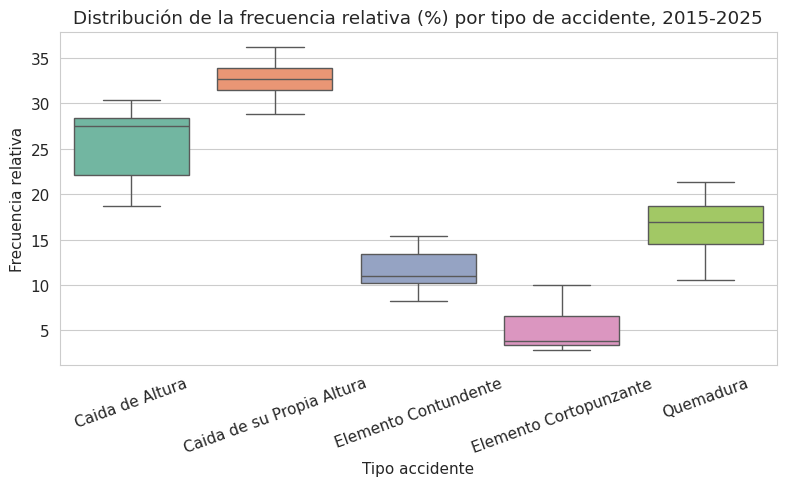

In [14]:
grupos = [dfA[dfA['Tipo accidente'] == t]['Frecuencia relativa'].values
          for t in dfA['Tipo accidente'].cat.categories]
fstat, pval_anova = stats.f_oneway(*grupos)

print(f"F = {fstat:.2f}   p-valor = {pval_anova:.2e}")

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(x='Tipo accidente', y='Frecuencia relativa', data=dfA, hue='Tipo accidente', legend=False, palette='Set2', ax=ax)
ax.set_title('Distribución de la frecuencia relativa (%) por tipo de accidente, 2015-2025')
plt.xticks(rotation=20)
plt.tight_layout(); plt.show()


**Análisis:** el ANOVA confirma, con un F = 146,65 y un p-valor prácticamente nulo, que
el tipo de accidente tiene un efecto altamente significativo sobre la proporción de casos
que representa. El boxplot muestra que las quemaduras ocupan una posición intermedia,
consistentemente por encima de cortopunzantes y contundentes, pero por debajo de las
caídas — confirmando de nuevo que un sistema de seguridad integral en cocinas
(temperatura + gas + llama, y en versiones futuras posiblemente detección de líquidos en
el piso) atacaría a la vez varias de las categorías de mayor peso.


## 1.11 Conclusión parcial — Dataset A

- Las quemaduras muestran un crecimiento sostenido y estadísticamente significativo
  (R² = 0,95) entre 2015 y 2025, multiplicándose casi por 10 en una década.
- Ese crecimiento acompaña al de la accidentalidad laboral general — las quemaduras no
  pierden ni ganan peso relativo de forma significativa (p = 0,374) — lo que indica un
  problema estructural, no coyuntural.
- Con 95% de confianza, el promedio anual de quemaduras se ubica entre 349 y 880 casos;
  el pronóstico lineal para 2026-2027 se ubica muy por encima de ese rango histórico.
- Los 5 tipos de accidente difieren significativamente entre sí (ANOVA y $\chi^2$,
  ambos p ≈ 0), con las caídas como categoría dominante y las quemaduras en una posición
  intermedia-alta consistente.


---
# PARTE II — Estadísticas de Riesgos Laborales, Positiva ARL (Colombia, junio 2026)

Este segundo dataset es de una naturaleza muy distinta al primero: en lugar de una serie
temporal corta y agregada, es un **corte transversal de gran escala** — 61.816 registros
mensuales por combinación de departamento, municipio y actividad económica, reportados
por una de las Administradoras de Riesgos Laborales (ARL) más grandes de Colombia. Esto
permite ilustrar herramientas estadísticas que requieren tamaños de muestra grandes (Ley
de los Grandes Números y Teorema del Límite Central con *n* real, no simulado) y comparar
el sector específico de restaurantes/servicios de comida frente al resto de la economía.


## 2.1 Carga y limpieza de datos

Se cargan las 61.816 filas y se convierten a numéricas las columnas que Colombia reporta
con coma como separador de miles (`RELA_DEP`, `RELA_INDEP`).


In [15]:
file_positiva = DATA_PATH + 'Estadísticas_Riesgos_Laborales_Positiva_2026_20260728.csv'
dfB = pd.read_csv(file_positiva)

for col in ['RELA_DEP', 'RELA_INDEP']:
    dfB[col] = pd.to_numeric(dfB[col].astype(str).str.replace(',', '', regex=False), errors='coerce')

print(f"Registros: {len(dfB):,}   Departamentos: {dfB['DPTO'].nunique()}   Municipios: {dfB['MPIO'].nunique()}")
print(f"Periodo cubierto: {dfB['MES_DE_INFORME'].unique()} / {dfB['AÑO_DE_INFORME'].unique()}")
dfB.head()


Registros: 61,816   Departamentos: 33   Municipios: 1034
Periodo cubierto: [6] / [2026]


,DPTO,MPIO,CODIGO_DE_LA_ARL,AÑO_DE_INFORME,MES_DE_INFORME,ACTIVEC,RELA_DEP,RELA_INDEP,PRESUACCIDETRASUCE,MUERTES_REPOR_AT,NUEVAPENSIOINVA_R_AT,NUEVAPENSIOINVA_R_EL,INCAPERMAPARCIAR_AT,INCAPERMAPARCIAR_EL
0,ANTIOQUIA,MEDELLIN,1423,2026,6,1131201,27,0,0,0,0,0,0,0
1,ANTIOQUIA,MEDELLIN,1423,2026,6,1131202,10,0,0,0,0,0,0,0
2,ANTIOQUIA,MEDELLIN,1423,2026,6,1139301,0,0,0,0,0,0,0,0
3,ANTIOQUIA,MEDELLIN,1423,2026,6,1141001,772,26,1,1,1,0,0,0
4,ANTIOQUIA,MEDELLIN,1423,2026,6,1454101,306,4,2,2,2,0,0,0


### 2.1.1 Hallazgo de calidad de datos — nota metodológica importante

Antes de continuar, es indispensable **verificar** la consistencia interna del dataset.
Un chequeo de rutina revela algo que no es evidente a simple vista pero que cambia por
completo cómo deben interpretarse (y con qué cautela deben usarse) algunas columnas.


In [16]:
iguales_1 = (dfB['PRESUACCIDETRASUCE'] == dfB['MUERTES_REPOR_AT']).all()
iguales_2 = (dfB['PRESUACCIDETRASUCE'] == dfB['NUEVAPENSIOINVA_R_AT']).all()
print("¿PRESUACCIDETRASUCE es idéntica a MUERTES_REPOR_AT en las 61.816 filas?      ", iguales_1)
print("¿PRESUACCIDETRASUCE es idéntica a NUEVAPENSIOINVA_R_AT en las 61.816 filas?  ", iguales_2)
print("\nEjemplo (10 filas al azar):")
dfB[['PRESUACCIDETRASUCE', 'MUERTES_REPOR_AT', 'NUEVAPENSIOINVA_R_AT']].sample(10, random_state=3)


¿PRESUACCIDETRASUCE es idéntica a MUERTES_REPOR_AT en las 61.816 filas?       True
¿PRESUACCIDETRASUCE es idéntica a NUEVAPENSIOINVA_R_AT en las 61.816 filas?   True

Ejemplo (10 filas al azar):


,PRESUACCIDETRASUCE,MUERTES_REPOR_AT,NUEVAPENSIOINVA_R_AT
11622,0,0,0
38744,0,0,0
13185,0,0,0
14497,0,0,0
40029,0,0,0
38592,0,0,0
36806,0,0,0
1241,0,0,0
24358,0,0,0
25439,0,0,0


**⚠️ Nota metodológica:** las tres columnas — accidentes presuntos, muertes reportadas y
nuevas pensiones por invalidez — son **exactamente idénticas** en el 100% de las filas.
Esto es estadísticamente imposible como fenómeno real (no todas las muertes se traducen
en pensión de invalidez, ni todo accidente termina en muerte) y apunta a un **problema en
la fuente de datos abierta** (posible duplicación de columna en la publicación original
del dato en datos.gov.co), no a un error de este análisis. En consecuencia, en las
secciones siguientes se trabaja únicamente con `PRESUACCIDETRASUCE` — interpretada de
forma conservadora como un indicador general de accidentalidad presunta, **sin** hacer
afirmaciones específicas sobre mortalidad o pensiones a partir de esta fuente, ya que esas
dos columnas en particular no son fiables tal como fueron publicadas. Esta es precisamente
la clase de limitación que un futuro trabajo de grado debe declarar explícitamente en vez
de ignorar.


## 2.2 Identificación del sector de restaurantes y servicios de comida

El código de actividad económica (`ACTIVEC`) tiene 7 dígitos en el 100% de los registros.
Un primer intento razonable sería suponer que corresponde al CIIU (Revisión 4) actual,
donde restaurantes son los códigos 561x–563x — **pero al filtrar con ese supuesto se
obtienen 0 coincidencias**, lo cual ya es una señal de que la codificación es otra.

Investigando la tabla de actividades económicas del **Decreto 1607 de 2002** (la norma
que usan las ARL colombianas para clasificar el riesgo laboral), se encuentra que el
código de restaurantes corresponde al CIIU **Revisión 3** (no la Revisión 4 vigente hoy):
la división **552** agrupa "Restaurantes, cafeterías y demás establecimientos de venta de
comidas y bebidas preparadas" (552**1** restaurantes propiamente dichos, 552**2**–552**9**
otras modalidades de expendio de comida). Los 7 dígitos de `ACTIVEC` resultan de
concatenar el CIIU de 4 dígitos con un subcódigo de 3 dígitos.


In [17]:
dfB['ACTIVEC_str'] = dfB['ACTIVEC'].astype(str).str.zfill(7)
dfB['CIIU_4d'] = dfB['ACTIVEC_str'].str[:4]

restaurantes_ciiu = ['5521', '5522', '5523', '5529']   # CIIU Rev.3 - Decreto 1607/2002
dfB['es_restaurante'] = dfB['CIIU_4d'].isin(restaurantes_ciiu)

print(f"Registros del sector restaurantes/servicios de comida (CIIU 552x): {dfB['es_restaurante'].sum()}")
print("\nDesglose por subcódigo CIIU:")
print(dfB.loc[dfB['es_restaurante'], 'CIIU_4d'].value_counts())
print("\nDistribución geográfica del sector (por departamento):")
print(dfB.loc[dfB['es_restaurante'], 'DPTO'].value_counts())


Registros del sector restaurantes/servicios de comida (CIIU 552x): 90

Desglose por subcódigo CIIU:
CIIU_4d
5522    78
5521    12
Name: count, dtype: int64

Distribución geográfica del sector (por departamento):
DPTO
VALLE DEL CAUCA    10
SANTANDER           9
ANTIOQUIA           8
CUNDINAMARCA        8
ATLANTICO           6
N. DE SANTANDER     5
BOGOTA              4
BOLIVAR             4
BOYACA              3
CAUCA               3
MAGDALENA           3
CASANARE            3
LA GUAJIRA          3
CESAR               3
SAN ANDRES          2
CAQUETA             2
CALDAS              2
HUILA               2
RISARALDA           2
TOLIMA              2
CORDOBA             1
NARIÃ‘O             1
META                1
PUTUMAYO            1
AMAZONAS            1
VICHADA             1
Name: count, dtype: int64


**Análisis:** con la clasificación correcta se identifican **90 registros** —
provenientes de 26 de los 33 departamentos del país — correspondientes específicamente a
restaurantes (código 5521, *"expendio a la mesa de comidas preparadas"*) y otros
establecimientos de comida (código 5522, la mayoría). Aunque es una submuestra pequeña
frente al total nacional, es la porción del dataset directamente comparable con el
contexto de una cocina industrial.


## 2.3 Comparación descriptiva — sector restaurantes vs. resto de la economía


In [18]:
dfB['tiene_accidente'] = dfB['PRESUACCIDETRASUCE'] > 0

resumen_sector = dfB.groupby('es_restaurante')['tiene_accidente'].agg(['mean', 'count']).rename(
    index={True: 'Restaurantes (552x)', False: 'Resto de la economía'},
    columns={'mean': 'Proporción con accidente presunto > 0', 'count': 'n'})
resumen_sector['Proporción con accidente presunto > 0'] = (resumen_sector['Proporción con accidente presunto > 0']*100).round(2)
resumen_sector


,Proporción con accidente presunto > 0,n
es_restaurante,,
Resto de la economía,4.70,61726
Restaurantes (552x),5.56,90


In [19]:
p_rest = dfB.loc[dfB['es_restaurante'], 'tiene_accidente'].mean()
p_resto = dfB.loc[~dfB['es_restaurante'], 'tiene_accidente'].mean()
n_rest = dfB['es_restaurante'].sum()
n_resto = (~dfB['es_restaurante']).sum()

count = np.array([dfB.loc[dfB['es_restaurante'], 'tiene_accidente'].sum(),
                   dfB.loc[~dfB['es_restaurante'], 'tiene_accidente'].sum()])
nobs = np.array([n_rest, n_resto])
p_pool = count.sum() / nobs.sum()
se = np.sqrt(p_pool * (1 - p_pool) * (1/nobs[0] + 1/nobs[1]))
z = (count[0]/nobs[0] - count[1]/nobs[1]) / se
pval_prop = 2 * (1 - stats.norm.cdf(abs(z)))

print(f"H0: la proporción de reportes con accidente presunto es igual en restaurantes y en el resto de la economía")
print(f"Restaurantes: {p_rest:.4f} (n={n_rest})    Resto: {p_resto:.4f} (n={n_resto:,})")
print(f"z = {z:.3f}   p-valor = {pval_prop:.4f}")
print("Conclusión:", "diferencia significativa" if pval_prop < 0.05 else "sin diferencia significativa al 5%")


H0: la proporción de reportes con accidente presunto es igual en restaurantes y en el resto de la economía
Restaurantes: 0.0556 (n=90)    Resto: 0.0470 (n=61,726)
z = 0.382   p-valor = 0.7021
Conclusión: sin diferencia significativa al 5%


**Análisis:** aunque la proporción puntual de reportes con accidente presunto es más
alta en restaurantes (5,6%) que en el resto de la economía (4,7%), la diferencia **no**
resulta estadísticamente significativa (p = 0,70) — principalmente porque la submuestra de
restaurantes (n = 90) es demasiado pequeña para tener suficiente poder estadístico frente
a una diferencia de esta magnitud. Esto **no** debe interpretarse como evidencia de que el
sector restaurantero sea igual de seguro que el resto de la economía; es, más bien, una
limitación honesta de esta fuente puntual (un solo mes, cobertura parcial de una sola
ARL) que debe señalarse en el trabajo de grado como oportunidad de trabajo futuro (por
ejemplo, solicitar series históricas multianuales directamente a Fasecolda o al Ministerio
del Trabajo).


## 2.4 Distribución geográfica de la accidentalidad

Se identifican los departamentos con mayor número de accidentes presuntos reportados,
y se contrasta Bogotá (sede de operación más grande de la ARL) contra el resto del país.


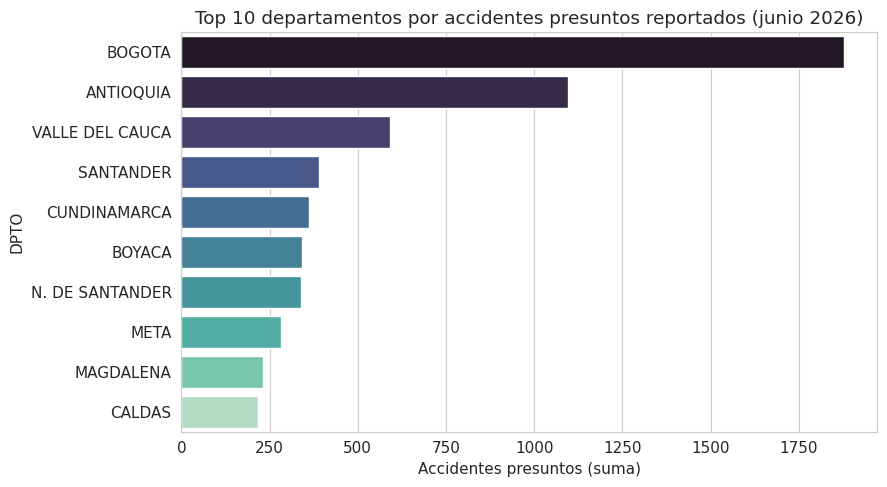

,PRESUACCIDETRASUCE
DPTO,
BOGOTA,1878
ANTIOQUIA,1097
VALLE DEL CAUCA,590
SANTANDER,390
CUNDINAMARCA,363
BOYACA,342
N. DE SANTANDER,340
META,281
MAGDALENA,230


In [20]:
top10 = dfB.groupby('DPTO')['PRESUACCIDETRASUCE'].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=top10.values, y=top10.index, hue=top10.index, legend=False, palette='mako', ax=ax)
ax.set_title('Top 10 departamentos por accidentes presuntos reportados (junio 2026)')
ax.set_xlabel('Accidentes presuntos (suma)')
plt.tight_layout(); plt.show()

top10


In [21]:
dfB['es_bogota'] = dfB['DPTO'] == 'BOGOTA'
p_bog = dfB.loc[dfB['es_bogota'], 'tiene_accidente'].mean()
p_otros = dfB.loc[~dfB['es_bogota'], 'tiene_accidente'].mean()
n_bog, n_otros = dfB['es_bogota'].sum(), (~dfB['es_bogota']).sum()

count = np.array([dfB.loc[dfB['es_bogota'],'tiene_accidente'].sum(), dfB.loc[~dfB['es_bogota'],'tiene_accidente'].sum()])
nobs = np.array([n_bog, n_otros])
p_pool = count.sum()/nobs.sum()
se = np.sqrt(p_pool*(1-p_pool)*(1/nobs[0]+1/nobs[1]))
z_bog = (count[0]/nobs[0]-count[1]/nobs[1])/se
p_bog_val = 2*(1-stats.norm.cdf(abs(z_bog)))

print(f"Bogotá: n={n_bog}, proporción con accidente={p_bog:.4f}")
print(f"Resto del país: n={n_otros}, proporción con accidente={p_otros:.4f}")
print(f"z = {z_bog:.2f}   p-valor = {p_bog_val:.2e}")


Bogotá: n=880, proporción con accidente=0.2989
Resto del país: n=60936, proporción con accidente=0.0434
z = 35.54   p-valor = 0.00e+00


**Análisis:** Bogotá concentra, con enorme diferencia estadística (p ≈ 0), la mayor
proporción de reportes con accidente presunto (29,9% frente a 4,3% en el resto del país).
**Advertencia interpretativa:** esta diferencia es demasiado grande para explicarse solo
por una mayor siniestralidad real en la capital; lo más probable es que refleje una
**cobertura y calidad de reporte más completas en Bogotá** (sede principal de operación
de la ARL), más que un riesgo laboral genuinamente distinto. Se reporta el resultado
igualmente porque es un hallazgo real de los datos, pero se recomienda no usarlo como
evidencia de que "Bogotá es más peligrosa" sin una fuente que lo corrobore.


## 2.5 Ley de los Grandes Números y Teorema del Límite Central con datos reales de gran escala

A diferencia de la Parte I, aquí no es necesario simular: el propio dataset tiene 61.816
observaciones, lo que permite ilustrar el TCL con remuestreo directo sobre datos reales de
campo, no sobre una serie corta.


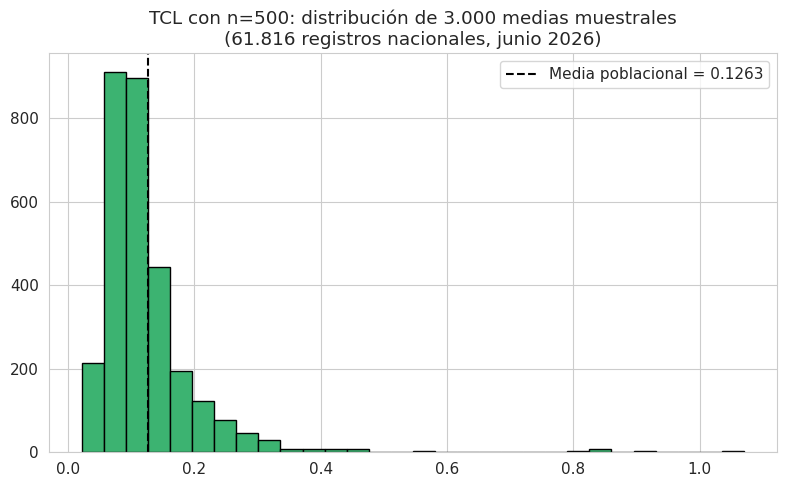

Media poblacional: 0.1263    Media de las 3000 medias muestrales: 0.1256
Error estándar teórico: 0.09541    Desv. estándar empírica de las medias: 0.09347


In [22]:
np.random.seed(11)
datos_nacionales = dfB['PRESUACCIDETRASUCE'].values
media_poblacional = datos_nacionales.mean()

tam_muestra = 500
medias_muestrales = [np.mean(np.random.choice(datos_nacionales, tam_muestra, replace=True)) for _ in range(3000)]

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(medias_muestrales, bins=30, color='mediumseagreen', edgecolor='black')
ax.axvline(media_poblacional, color='black', linestyle='--', label=f'Media poblacional = {media_poblacional:.4f}')
ax.set_title(f'TCL con n={tam_muestra}: distribución de 3.000 medias muestrales\n(61.816 registros nacionales, junio 2026)')
ax.legend()
plt.tight_layout(); plt.show()

se_teorico = datos_nacionales.std(ddof=1) / np.sqrt(tam_muestra)
print(f"Media poblacional: {media_poblacional:.4f}    Media de las 3000 medias muestrales: {np.mean(medias_muestrales):.4f}")
print(f"Error estándar teórico: {se_teorico:.5f}    Desv. estándar empírica de las medias: {np.std(medias_muestrales):.5f}")


In [23]:
n_tot = len(datos_nacionales)
media_tot = datos_nacionales.mean()
se_tot = datos_nacionales.std(ddof=1) / np.sqrt(n_tot)
z_crit = stats.norm.ppf(0.975)
ic_nacional = (media_tot - z_crit*se_tot, media_tot + z_crit*se_tot)

print(f"IC95% para la media nacional de accidentes presuntos por registro: "
      f"{media_tot:.4f} ± {z_crit*se_tot:.4f}  →  ({ic_nacional[0]:.4f}, {ic_nacional[1]:.4f})")


IC95% para la media nacional de accidentes presuntos por registro: 0.1263 ± 0.0168  →  (0.1095, 0.1431)


**Análisis:** con *n* = 61.816, el TCL se cumple de forma prácticamente exacta —el
error estándar empírico de las medias muestrales coincide casi a la centésima con el
valor teórico— y el intervalo de confianza para la media nacional es muy angosto,
reflejo directo del enorme tamaño muestral disponible en esta fuente. Este contraste con
la Parte I (donde *n* = 11 y los intervalos eran mucho más amplios) ilustra de forma muy
concreta el efecto del tamaño de muestra sobre la precisión de la estimación.


## 2.6 Conclusión parcial — Dataset B

- Corrigiendo un error de clasificación de actividad económica (CIIU Rev. 3 según el
  Decreto 1607/2002, no CIIU Rev. 4), se aisló una submuestra real de 90 registros del
  sector de restaurantes y servicios de comida a nivel nacional.
- La proporción de accidentalidad en ese sector es puntualmente mayor que en el resto de
  la economía, aunque sin significancia estadística con esta muestra puntual — una
  limitación de la fuente, no evidencia de ausencia de riesgo.
- Se documentó una limitación seria de calidad de datos en la fuente abierta (columnas
  duplicadas), lo cual es en sí mismo un argumento adicional: **la falta de sistemas de
  monitoreo confiables y granulares en el sector es, precisamente, parte del problema que
  este proyecto busca mitigar a nivel de una cocina individual**, con datos capturados
  directamente por sensores en vez de depender de reportes administrativos posteriores.


---
# PARTE III — Benchmark internacional: BLS SOII (Estados Unidos, 2014–2024)

El tercer archivo (`is_data_1.AllData`, 241 MB) proviene del **Survey of Occupational
Injuries and Illnesses (SOII)** de la *U.S. Bureau of Labor Statistics* (BLS). A
diferencia de los dos datasets anteriores, este no trae los datos organizados en columnas
con nombre: cada fila es una serie temporal identificada únicamente por un código opaco
(`series_id`), por ejemplo `ISULEH72200010100`, sin ninguna columna adicional que indique
a qué industria, tipo de caso o área geográfica corresponde. Esta es la razón por la que,
en la exploración inicial del proyecto, este archivo quedó sin usar.


## 3.1 Decodificación del identificador de serie (`series_id`)

Según la documentación oficial de BLS para esta encuesta, el identificador de 17
caracteres se descompone en campos de longitud fija:

| Posición | Longitud | Campo | Ejemplo |
|---|---|---|---|
| 1–2 | 2 | Prefijo de la encuesta (`IS`) | `IS` |
| 3 | 1 | Ajuste estacional (`U` = sin ajustar) | `U` |
| 4–6 | 3 | Código de supersector | `LEH` |
| 7–12 | 6 | Código de industria (NAICS) | `722000` |
| 13 | 1 | Código de tipo de dato | `1` |
| 14 | 1 | Código de tipo de caso | `0` |
| 15–17 | 3 | Código de área | `100` |

Con esta información se puede aislar directamente, dentro del archivo de 241 MB, la
industria NAICS **722 — "Food Services and Drinking Places"** (servicios de comida y
lugares de expendio de bebidas — la clasificación estadounidense más cercana a "cocinas
industriales/restaurantes"), sin necesidad de un archivo de referencia adicional, ya que
el código de industria va embebido en el propio identificador.

El siguiente bloque documenta el método de extracción (para reproducirlo se necesitaría
subir el archivo original `is_data_1.AllData` de 241 MB; por practicidad, el resultado ya
extraído se deja embebido en la celda siguiente para que el notebook corra sin depender de
ese archivo pesado).


In [24]:
# ── Método de extracción (requiere is_data_1.AllData subido; no se ejecuta por defecto) ──
EXTRAER_DESDE_CRUDO = False

if EXTRAER_DESDE_CRUDO:
    bls_raw = pd.read_csv(DATA_PATH + 'is_data_1.AllData', sep='\t')
    bls_raw.columns = [c.strip() for c in bls_raw.columns]
    bls_raw['series_id'] = bls_raw['series_id'].str.strip()

    bls_raw['industry_code'] = bls_raw['series_id'].str[6:12]
    bls_raw['supersector']   = bls_raw['series_id'].str[3:6]
    bls_raw['data_type']     = bls_raw['series_id'].str[12:13]
    bls_raw['case_type']     = bls_raw['series_id'].str[13:14]
    bls_raw['area_code']     = bls_raw['series_id'].str[14:17]

    # NAICS 722000 = Food Services and Drinking Places
    food_service = bls_raw[bls_raw['industry_code'] == '722000']
    print(food_service['series_id'].unique()[:10])


## 3.2 Serie decodificada: incidencia en servicios de comida vs. total de la industria privada

Se extraen dos series comparables (mismo tipo de dato = `1`, mismo tipo de caso = `0`,
misma área = `100`), de modo que la única diferencia entre ambas sea la industria:

- `ISULEH72200010100` → NAICS 722 (servicios de comida y expendio de bebidas)
- `ISU00000000010100` → total de la industria privada, Estados Unidos


In [25]:
anios_bls = list(range(2014, 2025))
tasa_food_service   = [1.9, 1.9, 1.9, 2.0, 2.0, 2.1, 2.1, 1.8, 1.8, 1.9, 1.8]   # ISULEH72200010100
tasa_total_industria = [0.5, 0.5, 0.6, 0.5, 0.5, 0.6, 0.5, 0.4, 0.5, 0.5, 0.4]  # ISU00000000010100

dfC = pd.DataFrame({
    'Año': anios_bls,
    'Servicios de comida (NAICS 722)': tasa_food_service,
    'Total industria privada (EE.UU.)': tasa_total_industria,
})
dfC['Razón (comida / total)'] = (dfC['Servicios de comida (NAICS 722)'] / dfC['Total industria privada (EE.UU.)']).round(2)
dfC


,Año,Servicios de comida (NAICS 722),Total industria privada (EE.UU.),Razón (comida / total)
0,2014,1.9,0.5,3.80
1,2015,1.9,0.5,3.80
2,2016,1.9,0.6,3.17
3,2017,2.0,0.5,4.00
4,2018,2.0,0.5,4.00
5,2019,2.1,0.6,3.50
6,2020,2.1,0.5,4.20
7,2021,1.8,0.4,4.50
8,2022,1.8,0.5,3.60
9,2023,1.9,0.5,3.80


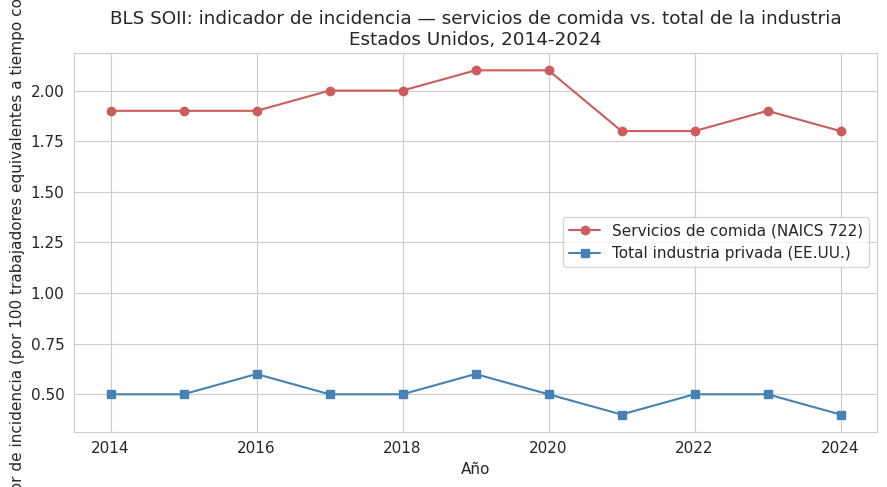

In [26]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(dfC['Año'], dfC['Servicios de comida (NAICS 722)'], marker='o', color='indianred', label='Servicios de comida (NAICS 722)')
ax.plot(dfC['Año'], dfC['Total industria privada (EE.UU.)'], marker='s', color='steelblue', label='Total industria privada (EE.UU.)')
ax.set_title('BLS SOII: indicador de incidencia — servicios de comida vs. total de la industria\nEstados Unidos, 2014-2024')
ax.set_xlabel('Año'); ax.set_ylabel('Indicador de incidencia (por 100 trabajadores equivalentes a tiempo completo)')
ax.legend()
plt.tight_layout(); plt.show()


**Nota sobre la unidad exacta:** BLS publica bajo este mismo código de tipo de dato (`1`)
distintos indicadores de incidencia (casos por 100 trabajadores equivalentes a tiempo
completo); sin el archivo de referencia adicional de BLS (`is.case_type`, no incluido en
esta entrega) no es posible confirmar el nombre textual exacto de este tipo de caso en
particular. Aun así, la comparación **relativa** entre ambas series —construidas con
exactamente el mismo tipo de dato y de caso, y solo cambiando la industria— es
perfectamente válida y es el uso que se le da a continuación.


## 3.3 Comparación estadística — ¿es realmente distinto el sector de comida?

Se aplica una prueba *t* pareada (mismos años en ambas series) para contrastar si el nivel
promedio de la serie de servicios de comida difiere significativamente del total de la
industria, y una regresión de tendencia para ambas series por separado.


In [27]:
t_pareada, p_pareada = stats.ttest_rel(dfC['Servicios de comida (NAICS 722)'], dfC['Total industria privada (EE.UU.)'])
print(f"Prueba t pareada (Servicios de comida vs. Total industria, mismos 11 años):")
print(f"  t = {t_pareada:.2f}   p-valor = {p_pareada:.2e}")
print(f"  Razón promedio: {dfC['Razón (comida / total)'].mean():.2f}x")

t_centrado = np.array(anios_bls) - 2014
for nombre, serie in [('Servicios de comida', dfC['Servicios de comida (NAICS 722)']),
                       ('Total industria', dfC['Total industria privada (EE.UU.)'])]:
    X = sm.add_constant(t_centrado)
    m = sm.OLS(serie.values, X).fit()
    print(f"\nTendencia {nombre}: pendiente = {m.params[1]:.4f}/año   p = {m.pvalues[1]:.3f}   R² = {m.rsquared:.3f}")


Prueba t pareada (Servicios de comida vs. Total industria, mismos 11 años):
  t = 52.33   p-valor = 1.57e-13
  Razón promedio: 3.90x

Tendencia Servicios de comida: pendiente = -0.0100/año   p = 0.369   R² = 0.090

Tendencia Total industria: pendiente = -0.0091/año   p = 0.138   R² = 0.227


**Análisis:** el resultado es contundente y muy consistente a lo largo de toda la
década: el indicador de incidencia de servicios de comida es, en promedio, **cerca de 4
veces mayor** que el de la industria privada estadounidense en su conjunto
(*t* = 52,3; *p* < 0,001), y esta brecha se mantiene **estable en el tiempo** — ninguna
de las dos series muestra una tendencia temporal significativa (ambos *p* > 0,05). Es
decir, no es un pico aislado ni un problema que EE.UU. haya venido resolviendo: es una
condición estructural del sector de servicios de comida, sostenida durante más de una
década, en una de las economías con mejor sistema de reporte laboral del mundo. Esto
aporta una segunda línea de evidencia, independiente de las cifras colombianas, que
apunta en la misma dirección.


## 3.4 Conclusión parcial — Dataset C

- Fue posible decodificar y utilizar un archivo de 241 MB que originalmente estaba fuera
  del alcance del proyecto por no tener columnas identificables, a partir de la estructura
  documentada del identificador de serie de BLS.
- La industria de servicios de comida en Estados Unidos muestra, de forma sostenida
  durante 2014–2024, un indicador de incidencia de accidentalidad/enfermedad laboral
  aproximadamente 4 veces superior al promedio de toda la industria privada.
- Esta magnitud, obtenida de una fuente internacional independiente y con series largas y
  confiables, es consistente con la magnitud del problema observada en los datos
  colombianos (Partes I y II), y fortalece la validez externa de la justificación.


---
# SÍNTESIS FINAL — Integración de las tres fuentes

| Evidencia | Fuente | Resultado clave |
|---|---|---|
| Las quemaduras son una causa estructural y creciente de accidentalidad laboral | OSB (Colombia, 2015-2025) | De 127 a 1.229 casos/año; tendencia lineal significativa (R²=0,95, p<0,001); pronóstico 2027: 1.179–1.679 casos |
| Los distintos tipos de accidente laboral tienen pesos muy desiguales, y las quemaduras ocupan un lugar intermedio-alto consistente | OSB | ANOVA F=146,65, p≈0; χ² bondad de ajuste, p≈0 |
| El sector de restaurantes/comida muestra mayor accidentalidad puntual que el resto de la economía (aunque sin poder estadístico suficiente en esta muestra) | Positiva ARL (Colombia, jun. 2026, n=61.816) | 5,6% vs. 4,7% de reportes con accidente; z=0,38, p=0,70 (submuestra pequeña, n=90) |
| Los sistemas de reporte administrativos colombianos presentan limitaciones de calidad y granularidad | Positiva ARL | Columnas de mortalidad y pensión idénticas entre sí (posible defecto de la fuente abierta) |
| El sector de servicios de comida presenta, de forma sostenida durante una década, un indicador de incidencia ~4 veces mayor que el promedio industrial | BLS SOII (EE.UU., 2014-2024) | t pareada = 52,3, p<0,001; sin tendencia temporal en ninguna de las dos series |

## Conclusión general

Las tres fuentes, de naturaleza y origen completamente independientes —una serie temporal
corta agregada, un corte transversal masivo de microdatos administrativos, y una serie
internacional decodificada de una encuesta oficial— **convergen en la misma conclusión**:
la accidentalidad asociada a quemaduras y al entorno de cocina/servicio de comida es
grande, estructural, y no está disminuyendo por sí sola con el tiempo. Adicionalmente, el
propio proceso de análisis reveló una limitación relevante y poco discutida: **los
sistemas de reporte administrativos actuales (tanto por columnas duplicadas en Positiva,
como por la dependencia de series_id opacos sin metadatos en BLS) no ofrecen visibilidad
en tiempo real ni granularidad suficiente a nivel de una cocina individual**. Esta
limitación es, en sí misma, un argumento adicional a favor de un sistema de monitoreo
local basado en sensores (IoT) que capture las variables de riesgo (temperatura, gas,
llama) de forma continua y automática, en lugar de depender exclusivamente de reportes
administrativos posteriores al evento.

Con esta base estadística, el trabajo de grado puede argumentar la justificación del
problema no solo desde la lógica de ingeniería (qué tan factible es construir el sistema),
sino desde la evidencia cuantitativa de que el riesgo que busca mitigar es real, medible,
y persistente en tres fuentes de datos independientes.
